In [29]:
import matplotlib.pyplot as plt
import pandas as pd




In [30]:
path = r'H:\python\trabalho_3etapa\atividade_5\Tabela4.csv'

In [31]:
# 1. Abrir um CSV com `;` e vírgula decimal
df = pd.read_csv(path, sep=";", skiprows=1, decimal=",", encoding="latin-1")

In [32]:
df.head()

,Sigla,Código,Estado,1991,2000,2010,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,AC,12,Acre,0.402,0.517,0.663,0.705,0.709,0.719,0.719,0.723,0.711,0.731,0.738,0.736,0.702,0.732,0.740,0.754
1,AL,27,Alagoas,0.370,0.471,0.631,0.657,0.653,0.670,0.669,0.680,0.682,0.694,0.693,0.694,0.691,0.722,0.739,0.746
2,AM,13,Amazonas,0.430,0.515,0.674,0.706,0.717,0.720,0.724,0.723,0.743,0.732,0.739,0.725,0.700,0.757,0.764,0.767
3,AP,16,Amapá,0.472,0.577,0.708,0.709,0.735,0.726,0.728,0.732,0.731,0.737,0.732,0.707,0.681,0.743,0.767,0.759
4,BA,29,Bahia,0.386,0.512,0.660,0.684,0.686,0.700,0.708,0.708,0.715,0.714,0.723,0.726,0.698,0.734,0.740,0.759


In [33]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 27 entries, 0 to 26
Data columns (total 19 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Sigla   27 non-null     str    
 1   Código  27 non-null     int64  
 2   Estado  27 non-null     str    
 3   1991    27 non-null     float64
 4   2000    27 non-null     float64
 5   2010    27 non-null     float64
 6   2012    27 non-null     float64
 7   2013    27 non-null     float64
 8   2014    27 non-null     float64
 9   2015    27 non-null     float64
 10  2016    27 non-null     float64
 11  2017    27 non-null     float64
 12  2018    27 non-null     float64
 13  2019    27 non-null     float64
 14  2020    27 non-null     float64
 15  2021    27 non-null     float64
 16  2022    27 non-null     float64
 17  2023    27 non-null     float64
 18  2024    27 non-null     float64
dtypes: float64(16), int64(1), str(2)
memory usage: 4.1 KB


In [34]:
# 2. Limpar colunas vazias
df_limpa= df.dropna(axis=1, how='all')

#salva atualizado
df_limpo = df.dropna(axis=1, thresh=10)


In [35]:
# 3. Ordene os estados por maior IDH em 2024

df_ordenado_2024 = df.sort_values(by="2024", ascending=False)

In [36]:
# 4. Qual estado teve a maior melhora de IDH entre os anos de 2024 e 1991?

df["Melhora"] = df["2024"] - df["1991"]
estado_maior_melhora = df.sort_values(by="Melhora", ascending=False).iloc[0]
print(
    f"{estado_maior_melhora['Estado']} ({estado_maior_melhora['Sigla']}) "
)

Tocantins (TO) 


In [37]:
# 5. Existe algum estado em que o IDH piorou?

piorou = df[df["2024"] < df["1991"]]
if piorou.empty:
    print("Nenhum estado piorou. Todos os estados apresentaram evolução no IDH.")
else:
    print(piorou[["Estado", "1991", "2024"]])

    

Nenhum estado piorou. Todos os estados apresentaram evolução no IDH.


In [38]:
# 5. Passar a tabela inicial do formato largo para o formato longo (`melt`)
anos = [c for c in df.columns if str(c).isdigit()]

id_vars = [c for c in df.columns if c not in anos]

df_longo = df.melt(
    id_vars=id_vars,
    value_vars=anos,
    var_name="Ano",
    value_name="IDH",
)

df_longo["Ano"] = df_longo["Ano"].astype(int)
df_longo["IDH"] = pd.to_numeric(df_longo["IDH"], errors="coerce")

print(df_longo.head())


  Sigla  Código    Estado  Melhora   Ano    IDH
0    AC      12      Acre    0.352  1991  0.402
1    AL      27   Alagoas    0.376  1991  0.370
2    AM      13  Amazonas    0.337  1991  0.430
3    AP      16     Amapá    0.287  1991  0.472
4    BA      29     Bahia    0.373  1991  0.386


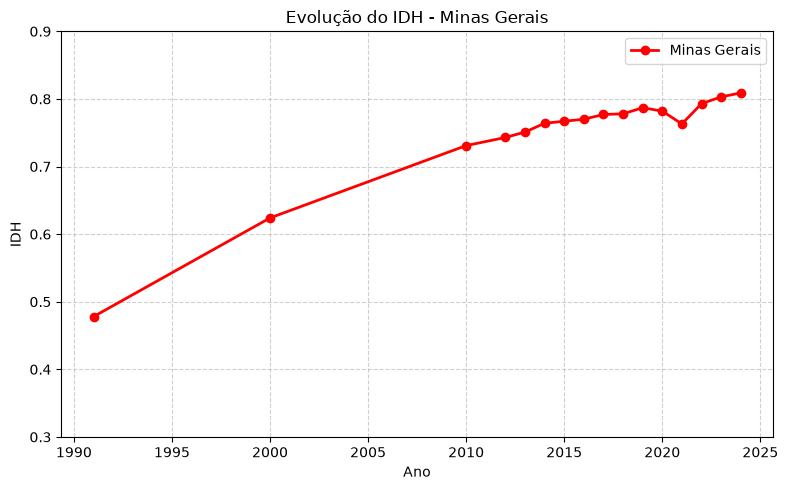

In [39]:
 # 6. Plote apenas Minas Gerais
fig_mg, ax_mg = plt.subplots(figsize=(8, 5))
df_mg = df_longo[df_longo["Sigla"] == "MG"].sort_values("Ano")
ax_mg.plot(
    df_mg["Ano"],
    df_mg["IDH"],
    marker="o",
    color="red",
    linewidth=2,
    label="Minas Gerais",
)
ax_mg.set_title("Evolução do IDH - Minas Gerais")
ax_mg.set_xlabel("Ano")
ax_mg.set_ylabel("IDH")
ax_mg.set_ylim(0.3, 0.9)
ax_mg.grid(True, linestyle="--", alpha=0.6)
ax_mg.legend()
fig_mg.tight_layout()


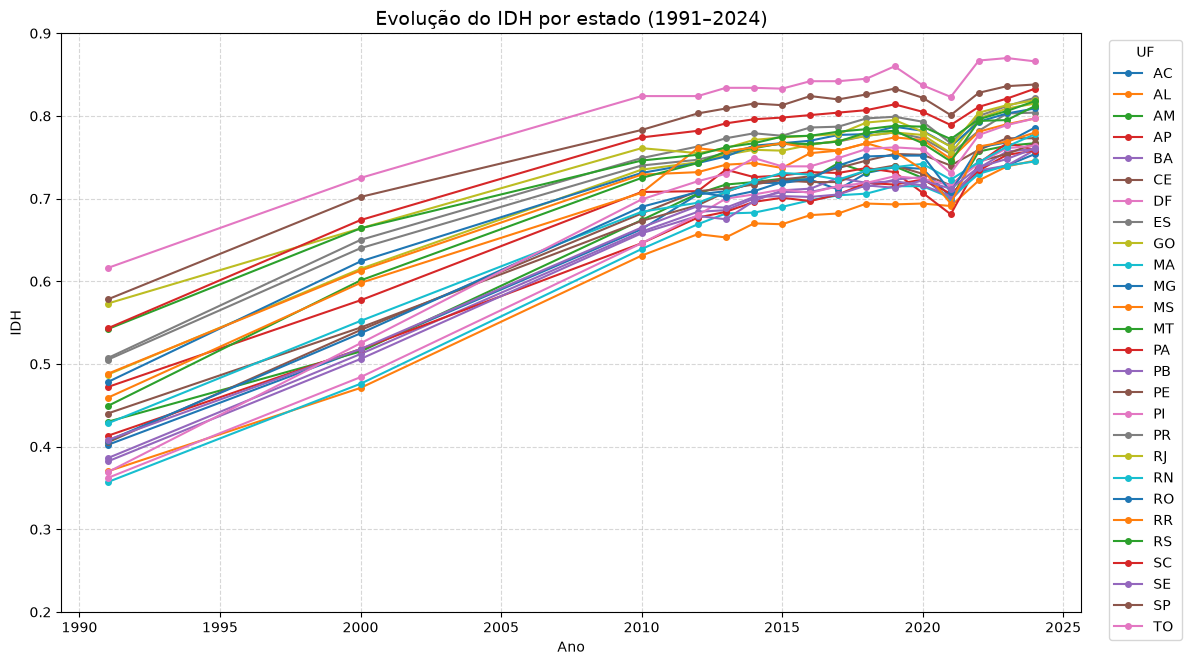

In [41]:

# 7. Plotar a evolução do IDH de cada estado

fig_todos, ax_todos = plt.subplots(figsize=(12, 7))
for sigla, grupo in df_longo.groupby("Sigla"):
    grupo = grupo.sort_values("Ano")
    ax_todos.plot(
        grupo["Ano"],
        grupo["IDH"],
        marker="o",
        markersize=4,
        linewidth=1.5,
        label=sigla,
    )

ax_todos.set_title("Evolução do IDH por estado (1991–2024)", fontsize=14)
ax_todos.set_xlabel("Ano")
ax_todos.set_ylabel("IDH")
ax_todos.set_ylim(0.2, 0.9)  # Ajustado o limite mínimo para captar os dados de 1991
ax_todos.grid(True, linestyle="--", alpha=0.5)
ax_todos.legend(ncol=1, bbox_to_anchor=(1.02, 1), loc="upper left", title="UF")
fig_todos.tight_layout()

